# Standard Imports

In [1]:
import os
import json
from pathlib import Path
from IPython.display import display, Image
from dotenv import load_dotenv

# OpenAI & ChromaDB - Embedding + Vector Store
import openai
import chromadb

# Image Processing
from PIL import Image as PILImage, ImageDraw
import pymupdf

# LandingAI SDK
from landingai_ade import LandingAIADE

---

# Configuration

In [2]:
# Setting Directories and Paths
DOC_PATH = "apple_10k.pdf"
OUTPUT_DIR = "./ade_outputs"
GROUNDING_DIR = f"{OUTPUT_DIR}/grounding"
ADE_JSON_PATH = f"{OUTPUT_DIR}/apple_10k.json"
ADE_MD_PATH = f"{OUTPUT_DIR}/apple_10k.md"

# Load API keys from .env
load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

---

# Chunk Normalization Function

In [3]:
def normalize_chunk(chunk):
    """Convert PosixPath objects in chunk dict to plain strings for JSON storage."""
    normalized = {}
    for k, v in chunk.items():
        if isinstance(v, Path):
            normalized[k] = str(v)
        elif isinstance(v, list):
            normalized[k] = [
                normalize_chunk(i) if isinstance(i, dict) else (str(i) if isinstance(i, Path) else i)
                for i in v
            ]
        elif isinstance(v, dict):
            normalized[k] = normalize_chunk(v)
        else:
            normalized[k] = v
    return normalized


def chunk_to_dict(chunk):
    """Convert a landingai_ade Chunk object to a normalized flat dict for storage."""
    return normalize_chunk({
        "chunk_id": chunk.id,
        "text": chunk.markdown,
        "chunk_type": chunk.type,
        "grounding": [
            {
                "page": chunk.grounding.page,
                "box": {
                    "left": chunk.grounding.box.left,
                    "top": chunk.grounding.box.top,
                    "right": chunk.grounding.box.right,
                    "bottom": chunk.grounding.box.bottom,
                }
            }
        ] if chunk.grounding else []
    })

---

# LandingAI - Agentic Document Extraction 10K Parsing

In [4]:
# LandingAI Python Library for Document Parsing
client = LandingAIADE(apikey=os.environ.get("VISION_AGENT_API_KEY"))
parse_response = client.parse(
    document=Path(DOC_PATH),
    model="dpt-2-latest",
)

# Normalize Chunks into JSON-Safe Format
normalized_chunks = [chunk_to_dict(c) for c in parse_response.chunks]

# Save Normalized Chunks
os.makedirs(OUTPUT_DIR, exist_ok=True)
with open(ADE_JSON_PATH, "w") as f:
    json.dump(normalized_chunks, f, indent=2)

# Save Markdown Output
with open(ADE_MD_PATH, "w") as f:
    f.write(parse_response.markdown)

print(f"""
Parsing Complete ✅
- Markdown: {ADE_MD_PATH}
- JSON: {ADE_JSON_PATH}
- Chunks parsed: {len(normalized_chunks)}
""")


Parsing Complete ✅
- Markdown: ./ade_outputs/apple_10k.md
- JSON: ./ade_outputs/apple_10k.json
- Chunks parsed: 453



---

# Bounding Box Visualization

Annotated image saved to: ./ade_outputs/viz/page_1_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_2_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_3_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_4_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_5_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_6_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_7_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_8_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_9_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_10_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_11_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_12_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_14_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_15_annotated.png
Annotated image saved to: ./ade_outputs/viz/page_16_annotated.png
Annotated image sav

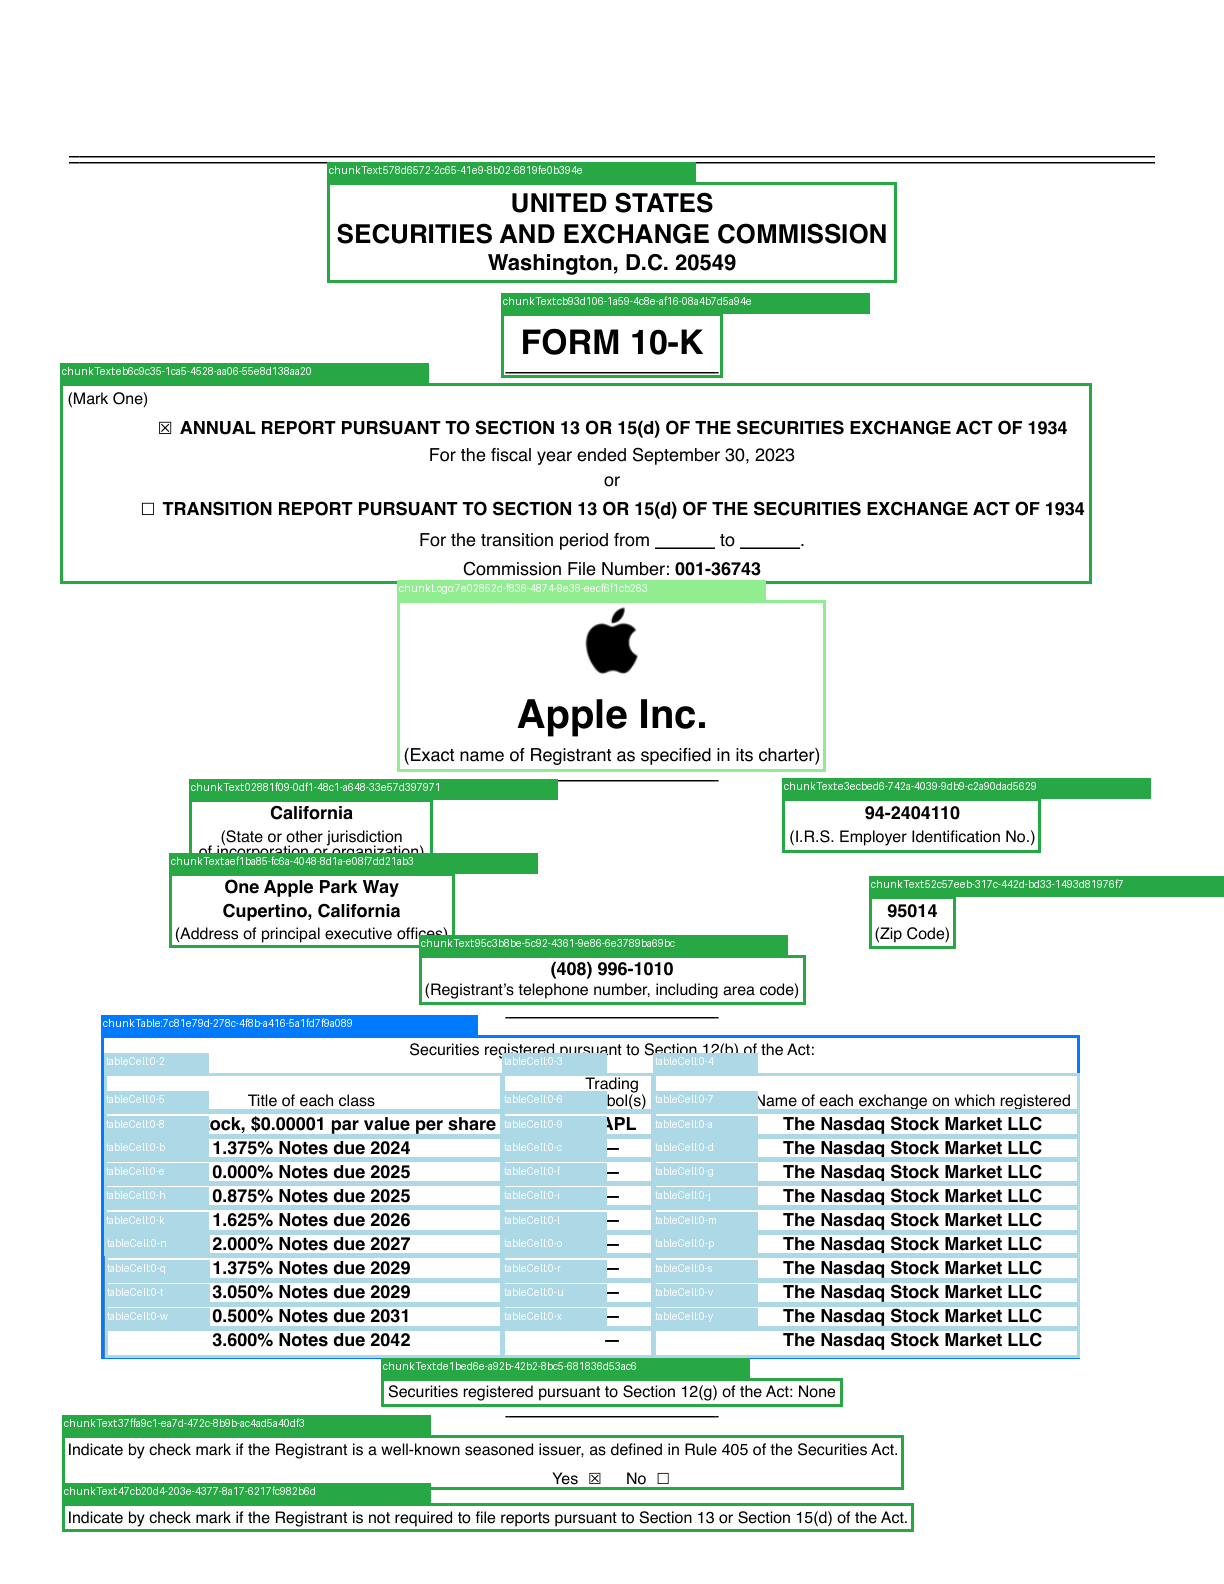

In [5]:
CHUNK_TYPE_COLORS = {
    "chunkText": (40, 167, 69),        # Green
    "chunkTable": (0, 123, 255),       # Blue
    "chunkMarginalia": (111, 66, 193), # Purple
    "chunkFigure": (255, 0, 255),      # Magenta
    "chunkLogo": (144, 238, 144),      # Light green
    "chunkCard": (255, 165, 0),        # Orange
    "chunkAttestation": (0, 255, 255), # Cyan
    "chunkScanCode": (255, 193, 7),    # Yellow
    "chunkForm": (220, 20, 60),        # Red
    "tableCell": (173, 216, 230),      # Light blue
    "table": (70, 130, 180),           # Steel blue
}


def draw_bounding_boxes(groundings, document_path, base_path="."):
    """
    Draw bounding boxes on document images to visualize parsed chunks.

    Args:
        groundings: Dictionary of grounding objects with chunk locations
        document_path: Path to the original document
        base_path: Directory to save annotated images
    """
    def create_annotated_image(image, groundings, page_num=0):
        annotated_img = image.copy()
        draw = ImageDraw.Draw(annotated_img)
        img_width, img_height = image.size

        groundings_found = 0
        for gid, grounding in groundings.items():
            if grounding.page != page_num:
                continue

            groundings_found += 1
            box = grounding.box
            x1 = int(box.left * img_width)
            y1 = int(box.top * img_height)
            x2 = int(box.right * img_width)
            y2 = int(box.bottom * img_height)

            color = CHUNK_TYPE_COLORS.get(grounding.type, (128, 128, 128))
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

            label = f"{grounding.type}:{gid}"
            label_y = max(0, y1 - 20)
            draw.rectangle([x1, label_y, x1 + len(label) * 8, y1], fill=color)
            draw.text((x1 + 2, label_y + 2), label, fill=(255, 255, 255))

        if groundings_found == 0:
            return None
        return annotated_img

    document_path = Path(document_path)
    os.makedirs(base_path, exist_ok=True)
    saved_paths = []

    if document_path.suffix.lower() == ".pdf":
        pdf = pymupdf.open(document_path)
        for page_num in range(len(pdf)):
            page = pdf[page_num]
            pix = page.get_pixmap(matrix=pymupdf.Matrix(2, 2))
            img = PILImage.frombytes("RGB", [pix.width, pix.height], pix.samples)
            annotated_img = create_annotated_image(img, groundings, page_num)
            if annotated_img is not None:
                annotated_path = f"{base_path}/page_{page_num + 1}_annotated.png"
                annotated_img.save(annotated_path)
                saved_paths.append(annotated_path)
                print(f"Annotated image saved to: {annotated_path}")
        pdf.close()
    else:
        img = PILImage.open(document_path)
        if img.mode != "RGB":
            img = img.convert("RGB")
        annotated_img = create_annotated_image(img, groundings)
        if annotated_img is not None:
            annotated_path = f"{base_path}/page_1_annotated.png"
            annotated_img.save(annotated_path)
            saved_paths.append(annotated_path)
            print(f"Annotated image saved to: {annotated_path}")

    return saved_paths


# Visualize parsed chunks for the 10K document
viz_dir = f"{OUTPUT_DIR}/viz"
saved = draw_bounding_boxes(parse_response.grounding, DOC_PATH, base_path=viz_dir)

# Display the first annotated page
if saved:
    display(PILImage.open(saved[0]))

# Chroma Initialization (Persistent Vector Store)

In [ ]:
# Instantiate the Chroma Client
chroma_client = chromadb.PersistentClient(path="./chroma_db")

# Delete and recreate collection to ensure fresh metadata schema
chroma_client.delete_collection(name="ade_documents")
collection = chroma_client.get_or_create_collection(name="ade_documents")

---

# Insert ADE Chunks into Chroma

In [ ]:
for chunk in normalized_chunks:
    text = chunk["text"]
    chunk_id = chunk["chunk_id"]
    grounding = chunk.get("grounding", [])

    # Flatten Metadata (Chroma requires no None values)
    if grounding:
        box = grounding[0]["box"]
        metadata = {
            "chunk_type": chunk["chunk_type"] or "",
            "page": grounding[0]["page"],
            "box_left": box["left"],
            "box_top": box["top"],
            "box_right": box["right"],
            "box_bottom": box["bottom"],
        }
    else:
        metadata = {
            "chunk_type": chunk["chunk_type"] or "",
            "page": -1,
            "box_left": 0.0,
            "box_top": 0.0,
            "box_right": 0.0,
            "box_bottom": 0.0,
        }

    # Generate Embeddings with OpenAI
    emb = openai.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    ).data[0].embedding

    # Store in Chroma
    collection.upsert(
        documents=[text],
        ids=[chunk_id],
        metadatas=[metadata],
        embeddings=[emb]
    )

print(f"Inserted {len(normalized_chunks)} chunks into Chroma with flat metadata ✅")

---

# RAG Query Function & Visualization

In [ ]:
def get_page_image(document_path, page_num, scale=2):
    """Render a single PDF page to a PIL image."""
    pdf = pymupdf.open(document_path)
    page = pdf[page_num]
    pix = page.get_pixmap(matrix=pymupdf.Matrix(scale, scale))
    img = PILImage.frombytes("RGB", [pix.width, pix.height], pix.samples)
    pdf.close()
    return img


def annotate_and_crop(document_path, page_num, box):
    """
    Returns (annotated_full_page, cropped_chunk) PIL images.
    box: dict with left/top/right/bottom as normalized floats.
    """
    img = get_page_image(document_path, page_num)
    w, h = img.size

    x1 = int(box["left"] * w)
    y1 = int(box["top"] * h)
    x2 = int(box["right"] * w)
    y2 = int(box["bottom"] * h)

    # Annotated full page
    annotated = img.copy()
    draw = ImageDraw.Draw(annotated)
    draw.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=4)

    # Cropped chunk with small padding
    pad = 8
    crop = img.crop((max(0, x1 - pad), max(0, y1 - pad),
                     min(w, x2 + pad), min(h, y2 + pad)))

    return annotated, crop


def rag_query(question, top_k=3, threshold=0.25):
    """
    Query the ADE Chroma index with a natural language question.

    Args:
        question (str): User query
        top_k (int): Max results to return
        threshold (float): Minimum similarity (1 - distance)
    """
    # 1. Embed Query
    q_embed = openai.embeddings.create(
        model="text-embedding-3-small",
        input=question
    ).data[0].embedding

    # 2. Query Chroma
    results = collection.query(
        query_embeddings=[q_embed],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

    print(f"\nQuery: {question}\n")

    retrieved_docs  = results["documents"][0]
    retrieved_meta  = results["metadatas"][0]
    retrieved_dists = results["distances"][0]
    retrieved_ids   = results["ids"][0]

    found_any = False
    for i, (doc, meta, dist, cid) in enumerate(zip(
        retrieved_docs, retrieved_meta, retrieved_dists, retrieved_ids
    )):
        similarity = 1 - dist
        if similarity < threshold:
            continue

        found_any = True
        page_num = meta.get("page", -1)
        print(f"Result {i+1} (score={similarity:.3f})")
        print(f"Chunk ID: {cid}")
        print(f"Chunk Type: {meta.get('chunk_type')}, Page: {page_num + 1}")
        print(f"Text: {doc[:200]}...")
        print("-" * 80)

        if page_num >= 0:
            box = {
                "left":   meta["box_left"],
                "top":    meta["box_top"],
                "right":  meta["box_right"],
                "bottom": meta["box_bottom"],
            }
            annotated_page, crop = annotate_and_crop(DOC_PATH, page_num, box)

            print("Cropped chunk:")
            display(crop)
            print("Annotated full page:")
            display(annotated_page)

    if not found_any:
        print("No results above similarity threshold.")

---

# Example RAG Query (Local)

HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK" (_client.py:1025)

🔎 Query: What was Apple’s net sales in 2023?

Result 1 (score=0.480): Net sales disaggregated by significant products and services for 2023, 2022 and 2021 were as follows (in millions):
<table><thead><tr><th></th><th>2023</th><th>...
Chunk ID: 8153133b-df10-4b9a-8cb5-7d034cc41076
Chunk Type: table, Page: 46
No grounding crop available
--------------------------------------------------------------------------------
Result 2 (score=0.480): Net sales disaggregated by significant products and services for 2023, 2022 and 2021 were as follows (in millions):
<table><thead><tr><th></th><th>2023</th><th>...
Chunk ID: e5de7089-d786-4d77-b78e-c9c80e34ad00
Chunk Type: table, Page: 46
Grounding available → ade_outputs/grounding/apple_10k_20250803_160816/page_46/ChunkType.table_e5de7089-d786-4d77-b78e-c9c80e34ad00_0.png


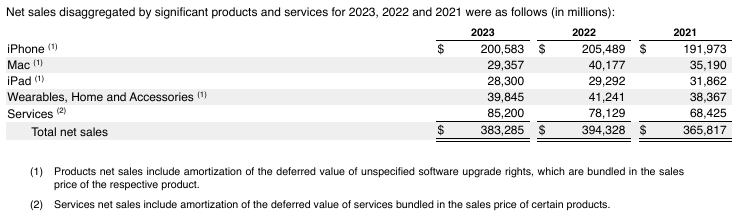

--------------------------------------------------------------------------------
Result 3 (score=0.380): *Americas*

Americas net sales decreased 4% or $7.1 billion during 2023 compared to 2022 due to lower net sales of iPhone and Mac, partially offset by higher ne...
Chunk ID: dcec30b7-f2cf-4ab8-814d-80acc500ca9e
Chunk Type: text, Page: 31
No grounding crop available
--------------------------------------------------------------------------------
Result 4 (score=0.380): *Americas*

Americas net sales decreased 4% or $7.1 billion during 2023 compared to 2022 due to lower net sales of iPhone and Mac, partially offset by higher ne...
Chunk ID: 6c63432a-ea6e-4534-8f9b-7ed138095d8b
Chunk Type: text, Page: 31
Grounding available → ade_outputs/grounding/apple_10k_20250803_160816/page_31/ChunkType.text_6c63432a-ea6e-4534-8f9b-7ed138095d8b_0.png


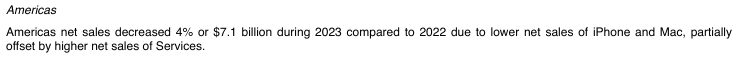

--------------------------------------------------------------------------------
Result 5 (score=0.378): *Mac*
Mac net sales decreased 27% or $10.8 billion during 2023 compared to 2022 due primarily to lower net sales of laptops....
Chunk ID: 39a047e7-b3a9-45d3-af75-1b755602d8b1
Chunk Type: text, Page: 32
No grounding crop available
--------------------------------------------------------------------------------


In [ ]:
# Pass in Question in Natural Language, Top_K, and Threhold/Cosine Distance
rag_query("What was Apple’s net sales in 2023?", top_k=5, threshold=0.32)